# Whisper-KDA vs Whisper-tiny

Сравнение моделей сопоставимого размера на NVIDIA T4, FP16, batch 16. Обе модели используют одинаковый синтетический словарь из 6390 токенов, соответствующий размеру итогового BPE-словаря проекта:

1. `teacher_forced_forward` — полный encoder + decoder forward при одинаковой длине decoder sequence;
2. `greedy_generation` — end-to-end жадная генерация.

Обе модели получают одинаковые синтетические log-Mel features и имеют случайно инициализированные веса. Whisper encoder и token embeddings точно копируются в Whisper-KDA; остальные decoder weights имеют разные формы из-за различий архитектур. В генерации KDA повторно использует штатное рекуррентное состояние, а Whisper на каждом шаге заново обрабатывает весь prefix с `use_cache=False`. Для Whisper проецируется только последний hidden state, поскольку только он нужен для следующего токена.

> Это сравнение скорости и ресурсов, а не качества распознавания. Оно измеряет конкретный no-cache режим Whisper и не заменяет отдельное сравнение со стандартным KV-cache.

In [2]:
%pip install -q "transformers==5.13.1" "flash-linear-attention[cuda]==0.5.2" pandas matplotlib

In [3]:
%cd /content

![ -d whisper-kda-asr/.git ] || git clone https://github.com/SummerSchoolSPBU2026/whisper-kda-asr.git
%cd /content/whisper-kda-asr
!git pull --ff-only

/content
Cloning into 'whisper-kda-asr'...
remote: Enumerating objects: 67, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 67 (delta 30), reused 55 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (67/67), 670.61 KiB | 2.52 MiB/s, done.
Resolving deltas: 100% (30/30), done.
/content/whisper-kda-asr
Already up to date.


In [4]:
import gc
import math
import statistics
import subprocess
import threading
import time

import matplotlib.pyplot as plt
import pandas as pd
import torch
from transformers import (
    WhisperConfig,
    WhisperForConditionalGeneration,
)

from model import WhisperKDAModel, create_kda_config

torch.manual_seed(42)

if not torch.cuda.is_available():
    raise RuntimeError("Для benchmark нужна CUDA GPU")

device = torch.device("cuda")
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(device))

PyTorch: 2.11.0+cu128
CUDA: 12.8
GPU: Tesla T4


In [5]:
WHISPER_MODEL_NAME = "openai/whisper-tiny"
BENCHMARK_VOCAB_SIZE = 6390
RANDOM_SEED = 42

whisper_config = WhisperConfig.from_pretrained(WHISPER_MODEL_NAME)
whisper_config._attn_implementation = "sdpa"
whisper_config.use_cache = False
whisper_config.vocab_size = BENCHMARK_VOCAB_SIZE
whisper_config.pad_token_id = 1
whisper_config.bos_token_id = 2
whisper_config.eos_token_id = 3
whisper_config.decoder_start_token_id = 2
whisper_config.suppress_tokens = []
whisper_config.begin_suppress_tokens = []
whisper_config.forced_decoder_ids = None


class BenchmarkVocabulary:
    pad_token_id = whisper_config.pad_token_id
    bos_token_id = whisper_config.bos_token_id
    eos_token_id = whisper_config.eos_token_id

    def __len__(self):
        return BENCHMARK_VOCAB_SIZE


benchmark_vocabulary = BenchmarkVocabulary()
assert len({
    benchmark_vocabulary.pad_token_id,
    benchmark_vocabulary.bos_token_id,
    benchmark_vocabulary.eos_token_id,
}) == 3

torch.manual_seed(RANDOM_SEED)
whisper_model = WhisperForConditionalGeneration(whisper_config).eval()
whisper_model.model.encoder.requires_grad_(False)

print("Shared vocabulary size:", len(benchmark_vocabulary))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/1.98k [00:00<?, ?B/s]

Shared vocabulary size: 6390


## Параметры

Код измеряет полную длину decoder sequence `64/128/256/448`, включая один стартовый токен. Короткие длины показывают накладные расходы, а `256/448` — область, где должна проявляться разница масштабирования. `448` является максимальной штатной длиной decoder у Whisper-tiny. `BATCH_SIZE = 16`.

In [6]:
BATCH_SIZE = 16
BENCHMARK_LENGTHS = (64, 128, 256, 448)
PROMPT_LENGTH = 1
WARMUP_RUNS = 1
MEASURED_RUNS = 3
RESOURCE_PROFILE_SECONDS = 0.5
RESOURCE_SAMPLE_INTERVAL_SECONDS = 0.05

# Полный синтетический 30-секундный вход не содержит padding,
# поэтому attention mask здесь намеренно не передаётся.
input_features = torch.randn(
    BATCH_SIZE,
    80,
    3000,
    dtype=torch.float32,
    device=device,
)

print("input_features:", tuple(input_features.shape))
print("decoder lengths:", BENCHMARK_LENGTHS)

input_features: (16, 80, 3000)
decoder lengths: (64, 128, 256, 448)


In [7]:
def synchronize():
    torch.cuda.synchronize(device)


def percentile(values, fraction):
    ordered = sorted(values)
    index = min(len(ordered) - 1, math.ceil(fraction * len(ordered)) - 1)
    return ordered[index]


def parameter_count(model):
    return sum(parameter.numel() for parameter in model.parameters())


def trainable_parameter_count(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


def parameter_memory_mb(model):
    return sum(
        parameter.numel() * parameter.element_size()
        for parameter in model.parameters()
    ) / 1024**2


def benchmark_call(call, warmup_runs=WARMUP_RUNS, measured_runs=MEASURED_RUNS):
    synchronize()
    warmup_start = time.perf_counter()
    for _ in range(warmup_runs):
        call()
    synchronize()
    warmup_seconds = time.perf_counter() - warmup_start

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(device)

    timings = []
    for _ in range(measured_runs):
        synchronize()
        start = time.perf_counter()
        call()
        synchronize()
        timings.append(time.perf_counter() - start)

    return {
        "warmup_seconds": warmup_seconds,
        "mean_ms": statistics.mean(timings) * 1000,
        "median_ms": statistics.median(timings) * 1000,
        "p90_ms": percentile(timings, 0.90) * 1000,
        "min_ms": min(timings) * 1000,
        "peak_memory_mb": torch.cuda.max_memory_allocated(device) / 1024**2,
        "peak_reserved_mb": torch.cuda.max_memory_reserved(device) / 1024**2,
    }


class NvidiaSmiSampler:
    def __init__(self, interval_seconds=0.1):
        self.interval_seconds = interval_seconds
        self.samples = []
        self.stop_event = threading.Event()
        self.thread = None

    def _sample(self):
        completed = subprocess.run(
            [
                "nvidia-smi",
                "-i",
                str(torch.cuda.current_device()),
                "--query-gpu=power.draw,utilization.gpu,memory.used",
                "--format=csv,noheader,nounits",
            ],
            check=True,
            capture_output=True,
            text=True,
        )
        power_w, utilization_pct, memory_mb = [
            float(value.strip())
            for value in completed.stdout.strip().split(",")
        ]
        self.samples.append({
            "power_w": power_w,
            "utilization_pct": utilization_pct,
            "device_memory_mb": memory_mb,
        })

    def _run(self):
        while not self.stop_event.is_set():
            try:
                self._sample()
            except (FileNotFoundError, subprocess.SubprocessError, ValueError):
                pass
            self.stop_event.wait(self.interval_seconds)

    def start(self):
        self.thread = threading.Thread(target=self._run, daemon=True)
        self.thread.start()

    def stop(self):
        self.stop_event.set()
        self.thread.join()


def profile_resources(call, minimum_seconds=RESOURCE_PROFILE_SECONDS):
    sampler = NvidiaSmiSampler(RESOURCE_SAMPLE_INTERVAL_SECONDS)
    synchronize()
    sampler.start()
    start = time.perf_counter()
    calls = 0

    while time.perf_counter() - start < minimum_seconds:
        call()
        synchronize()
        calls += 1

    elapsed_seconds = time.perf_counter() - start
    sampler.stop()

    if not sampler.samples:
        return {
            "resource_profile_seconds": elapsed_seconds,
            "resource_profile_calls": calls,
            "avg_gpu_utilization_pct": None,
            "max_gpu_utilization_pct": None,
            "avg_power_w": None,
            "max_power_w": None,
            "estimated_energy_per_call_j": None,
            "peak_device_memory_mb": None,
        }

    average_power_w = statistics.mean(
        sample["power_w"] for sample in sampler.samples
    )

    return {
        "resource_profile_seconds": elapsed_seconds,
        "resource_profile_calls": calls,
        "avg_gpu_utilization_pct": statistics.mean(
            sample["utilization_pct"] for sample in sampler.samples
        ),
        "max_gpu_utilization_pct": max(
            sample["utilization_pct"] for sample in sampler.samples
        ),
        "avg_power_w": average_power_w,
        "max_power_w": max(sample["power_w"] for sample in sampler.samples),
        "estimated_energy_per_call_j": average_power_w * elapsed_seconds / calls,
        "peak_device_memory_mb": max(
            sample["device_memory_mb"] for sample in sampler.samples
        ),
    }


def release_cuda_memory():
    gc.collect()
    torch.cuda.empty_cache()
    synchronize()


results = []

## Whisper-KDA

Модель загружается и измеряется отдельно, чтобы веса второй модели не попадали в peak GPU memory.

In [8]:
kda_config = create_kda_config(
    tokenizer=benchmark_vocabulary,
    max_target_length=max(BENCHMARK_LENGTHS),
    freeze_encoder=True,
)

torch.manual_seed(RANDOM_SEED)
kda_model = WhisperKDAModel(config=kda_config)
parameter_gap = abs(
    parameter_count(kda_model) - parameter_count(whisper_model)
) / parameter_count(whisper_model)
assert parameter_gap < 0.02, (
    f"Models differ by {parameter_gap:.2%} parameters"
)
kda_model.encoder.load_state_dict(
    whisper_model.model.encoder.state_dict()
)
with torch.no_grad():
    kda_model.decoder.model.embeddings.weight.copy_(
        whisper_model.model.decoder.embed_tokens.weight
    )

encoder_weights_equal = all(
    torch.equal(kda_parameter, whisper_parameter)
    for kda_parameter, whisper_parameter in zip(
        kda_model.encoder.parameters(),
        whisper_model.model.encoder.parameters(),
    )
)
assert encoder_weights_equal, "Encoder weights должны полностью совпадать"
assert torch.equal(
    kda_model.decoder.model.embeddings.weight,
    whisper_model.model.decoder.embed_tokens.weight,
), "Token embedding weights должны полностью совпадать"
print(
    "Parameters, M:",
    round(parameter_count(kda_model) / 1e6, 3),
    round(parameter_count(whisper_model) / 1e6, 3),
)

load_start = time.perf_counter()
kda_model = kda_model.to(device).eval()
synchronize()
kda_load_seconds = time.perf_counter() - load_start
kda_baseline_memory_mb = (
    torch.cuda.memory_allocated(device) / 1024**2
)


def add_kda_result(
    call,
    *,
    benchmark,
    decoder_length,
    generation_state,
    processed_tokens,
):
    print(f"[KDA] {benchmark}, length={decoder_length}")
    result = benchmark_call(call)
    result.update(profile_resources(call))
    result.update({
        "model": "Whisper-KDA",
        "benchmark": benchmark,
        "decoder_length": decoder_length,
        "generation_state": generation_state,
        "load_seconds": kda_load_seconds,
        "parameters_m": parameter_count(kda_model) / 1e6,
        "trainable_parameters_m": (
            trainable_parameter_count(kda_model) / 1e6
        ),
        "parameter_memory_mb": parameter_memory_mb(kda_model),
        "baseline_memory_mb": kda_baseline_memory_mb,
        "processed_tokens": processed_tokens,
    })
    result["incremental_peak_memory_mb"] = max(
        0.0,
        result["peak_memory_mb"] - kda_baseline_memory_mb,
    )
    results.append(result)


def make_kda_forward(text_length):
    decoder_ids = torch.full(
        (BATCH_SIZE, text_length),
        kda_config.bos_token_id,
        dtype=torch.long,
        device=device,
    )

    @torch.inference_mode()
    def call():
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            encoder_hidden_states, _ = kda_model.encode(
                input_features=input_features,
                attention_mask=None,
            )
            output = kda_model.decoder(
                input_ids=decoder_ids,
                encoder_hidden_states=encoder_hidden_states,
                decoder_attention_mask=None,
                encoder_attention_mask=None,
                use_cache=False,
                return_dict=True,
            )
            _ = output.logits[:, -1, 0]

    return call


def make_kda_generate(total_length):
    max_new_tokens = total_length - PROMPT_LENGTH
    prompt_ids = [
        kda_config.decoder_start_token_id,
        *kda_config.decoder_prompt_ids,
    ]
    assert len(prompt_ids) == PROMPT_LENGTH

    @torch.inference_mode()
    def call():
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            encoder_hidden_states, _ = kda_model.encode(
                input_features=input_features,
                attention_mask=None,
            )
            generated_ids = torch.tensor(
                prompt_ids,
                dtype=torch.long,
                device=device,
            ).unsqueeze(0).repeat(BATCH_SIZE, 1)
            past_key_values = None

            for _ in range(max_new_tokens):
                step_input_ids = (
                    generated_ids[:, -1:]
                    if past_key_values is not None
                    else generated_ids
                )

                decoder_output = kda_model.decoder(
                    input_ids=step_input_ids,
                    encoder_hidden_states=encoder_hidden_states,
                    decoder_attention_mask=None,
                    encoder_attention_mask=None,
                    past_key_values=past_key_values,
                    use_cache=True,
                    return_dict=True,
                )

                next_token = decoder_output.logits[:, -1].argmax(
                    dim=-1,
                    keepdim=True,
                )
                generated_ids = torch.cat(
                    [generated_ids, next_token],
                    dim=1,
                )
                past_key_values = decoder_output.past_key_values

        generated_tokens = generated_ids.size(1) - len(prompt_ids)
        if generated_tokens != max_new_tokens:
            raise RuntimeError(
                f"KDA generated {generated_tokens} tokens, "
                f"expected {max_new_tokens}"
            )
    return call


for decoder_length in BENCHMARK_LENGTHS:
    add_kda_result(
        make_kda_forward(decoder_length),
        benchmark="teacher_forced_forward",
        decoder_length=decoder_length,
        generation_state="none",
        processed_tokens=BATCH_SIZE * decoder_length,
    )
    add_kda_result(
        make_kda_generate(decoder_length),
        benchmark="greedy_generation",
        decoder_length=decoder_length,
        generation_state="KDA recurrent state",
        processed_tokens=(
            BATCH_SIZE * (decoder_length - PROMPT_LENGTH)
        ),
    )
print("KDA load, s:", round(kda_load_seconds, 3))

del kda_model
release_cuda_memory()

model.safetensors: reconstructing file:   0%|          |  0.00B /  151MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

Parameters, M: 20.535 20.298
[KDA] teacher_forced_forward, length=64
[KDA] greedy_generation, length=64
[KDA] teacher_forced_forward, length=128
[KDA] greedy_generation, length=128
[KDA] teacher_forced_forward, length=256
[KDA] greedy_generation, length=256
[KDA] teacher_forced_forward, length=448
[KDA] greedy_generation, length=448
KDA load, s: 0.037


## Обычный Whisper-tiny

In [9]:
load_start = time.perf_counter()
whisper_model = whisper_model.to(device).eval()
synchronize()
whisper_load_seconds = time.perf_counter() - load_start
whisper_baseline_memory_mb = (
    torch.cuda.memory_allocated(device) / 1024**2
)
whisper_decoder_start = whisper_model.config.decoder_start_token_id
def add_whisper_result(
    call,
    *,
    benchmark,
    decoder_length,
    generation_state,
    processed_tokens,
):
    print(f"[Whisper] {benchmark}, length={decoder_length}")
    result = benchmark_call(call)
    result.update(profile_resources(call))
    result.update({
        "model": "Whisper-tiny",
        "benchmark": benchmark,
        "decoder_length": decoder_length,
        "generation_state": generation_state,
        "load_seconds": whisper_load_seconds,
        "parameters_m": parameter_count(whisper_model) / 1e6,
        "trainable_parameters_m": (
            trainable_parameter_count(whisper_model) / 1e6
        ),
        "parameter_memory_mb": parameter_memory_mb(whisper_model),
        "baseline_memory_mb": whisper_baseline_memory_mb,
        "processed_tokens": processed_tokens,
    })
    result["incremental_peak_memory_mb"] = max(
        0.0,
        result["peak_memory_mb"] - whisper_baseline_memory_mb,
    )
    results.append(result)


def make_whisper_forward(text_length):
    decoder_ids = torch.full(
        (BATCH_SIZE, text_length),
        whisper_decoder_start,
        dtype=torch.long,
        device=device,
    )

    @torch.inference_mode()
    def call():
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            output = whisper_model(
                input_features=input_features,
                attention_mask=None,
                decoder_input_ids=decoder_ids,
                use_cache=False,
            )
            _ = output.logits[:, -1, 0]

    return call


def make_whisper_generate(total_length):
    max_new_tokens = total_length - PROMPT_LENGTH
    prompt_ids = torch.full(
        (BATCH_SIZE, PROMPT_LENGTH),
        whisper_decoder_start,
        dtype=torch.long,
        device=device,
    )

    @torch.inference_mode()
    def call():
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            encoder_hidden_states = (
                whisper_model.model.encoder(
                    input_features=input_features,
                    attention_mask=None,
                    return_dict=True,
                ).last_hidden_state
            )

            generated_ids = prompt_ids.clone()

            for _ in range(max_new_tokens):
                decoder_output = whisper_model.model.decoder(
                    input_ids=generated_ids,
                    encoder_hidden_states=encoder_hidden_states,
                    use_cache=False,
                    return_dict=True,
                )

                logits = whisper_model.proj_out(
                    decoder_output.last_hidden_state[:, -1:]
                )
                next_token = logits[:, -1].argmax(
                    dim=-1,
                    keepdim=True,
                )
                generated_ids = torch.cat(
                    [generated_ids, next_token],
                    dim=1,
                )

        generated_tokens = generated_ids.size(1) - PROMPT_LENGTH
        if generated_tokens != max_new_tokens:
            raise RuntimeError(
                f"Whisper generated {generated_tokens} tokens, "
                f"expected {max_new_tokens}"
            )
    return call


for decoder_length in BENCHMARK_LENGTHS:
    add_whisper_result(
        make_whisper_forward(decoder_length),
        benchmark="teacher_forced_forward",
        decoder_length=decoder_length,
        generation_state="none",
        processed_tokens=BATCH_SIZE * decoder_length,
    )
    add_whisper_result(
        make_whisper_generate(decoder_length),
        benchmark="greedy_generation",
        decoder_length=decoder_length,
        generation_state="none",
        processed_tokens=(
            BATCH_SIZE * (decoder_length - PROMPT_LENGTH)
        ),
    )
print("Whisper load, s:", round(whisper_load_seconds, 3))

del whisper_model
release_cuda_memory()

[Whisper] teacher_forced_forward, length=64
[Whisper] greedy_generation, length=64
[Whisper] teacher_forced_forward, length=128
[Whisper] greedy_generation, length=128
[Whisper] teacher_forced_forward, length=256
[Whisper] greedy_generation, length=256
[Whisper] teacher_forced_forward, length=448
[Whisper] greedy_generation, length=448
Whisper load, s: 0.036


## Результаты

Новый запуск сохраняется отдельно в `whisper_kda_vs_whisper_tiny_t4_batch16_vocab6390_no_cache.csv`, чтобы не смешивать результаты с прежним benchmark на полном Whisper vocabulary. После появления CSV последнюю ячейку можно выполнять отдельно в CPU runtime.

,gpu,precision,batch_size,model,benchmark,decoder_length,generation_state,parameters_m,incremental_peak_memory_mb,median_ms,tokens_per_second,avg_gpu_utilization_pct,avg_power_w,estimated_energy_per_token_j
0,Tesla T4,FP16,16,Whisper-KDA,teacher_forced_forward,64,none,20.535,275.223,89.696,11416.319,98.571,67.543,0.006
1,Tesla T4,FP16,16,Whisper-KDA,greedy_generation,64,KDA recurrent state,20.535,275.215,1123.750,896.997,99.714,67.358,0.076
2,Tesla T4,FP16,16,Whisper-KDA,teacher_forced_forward,128,none,20.535,275.230,110.899,18467.212,99.286,64.470,0.004
3,Tesla T4,FP16,16,Whisper-KDA,greedy_generation,128,KDA recurrent state,20.535,275.215,2518.117,806.952,99.774,64.663,0.081
4,Tesla T4,FP16,16,Whisper-KDA,teacher_forced_forward,256,none,20.535,275.246,121.001,33851.084,99.625,64.876,0.002
5,Tesla T4,FP16,16,Whisper-KDA,greedy_generation,256,KDA recurrent state,20.535,275.215,5050.870,807.782,99.903,64.551,0.079
6,Tesla T4,FP16,16,Whisper-KDA,teacher_forced_forward,448,none,20.535,275.270,132.678,54025.347,99.286,63.653,0.001
7,Tesla T4,FP16,16,Whisper-KDA,greedy_generation,448,KDA recurrent state,20.535,275.215,8655.874,826.260,99.346,65.712,0.077
8,Tesla T4,FP16,16,Whisper-tiny,teacher_forced_forward,64,none,20.298,265.379,89.713,11414.149,98.571,67.324,0.006
9,Tesla T4,FP16,16,Whisper-tiny,greedy_generation,64,none,20.298,265.372,748.414,1346.848,93.222,66.600,0.049


,KDA speedup vs Whisper,"KDA memory saving, %"
decoder_length,,
64,0.666,-3.709
128,0.626,-3.709
256,0.766,-3.709
448,1.082,-3.709


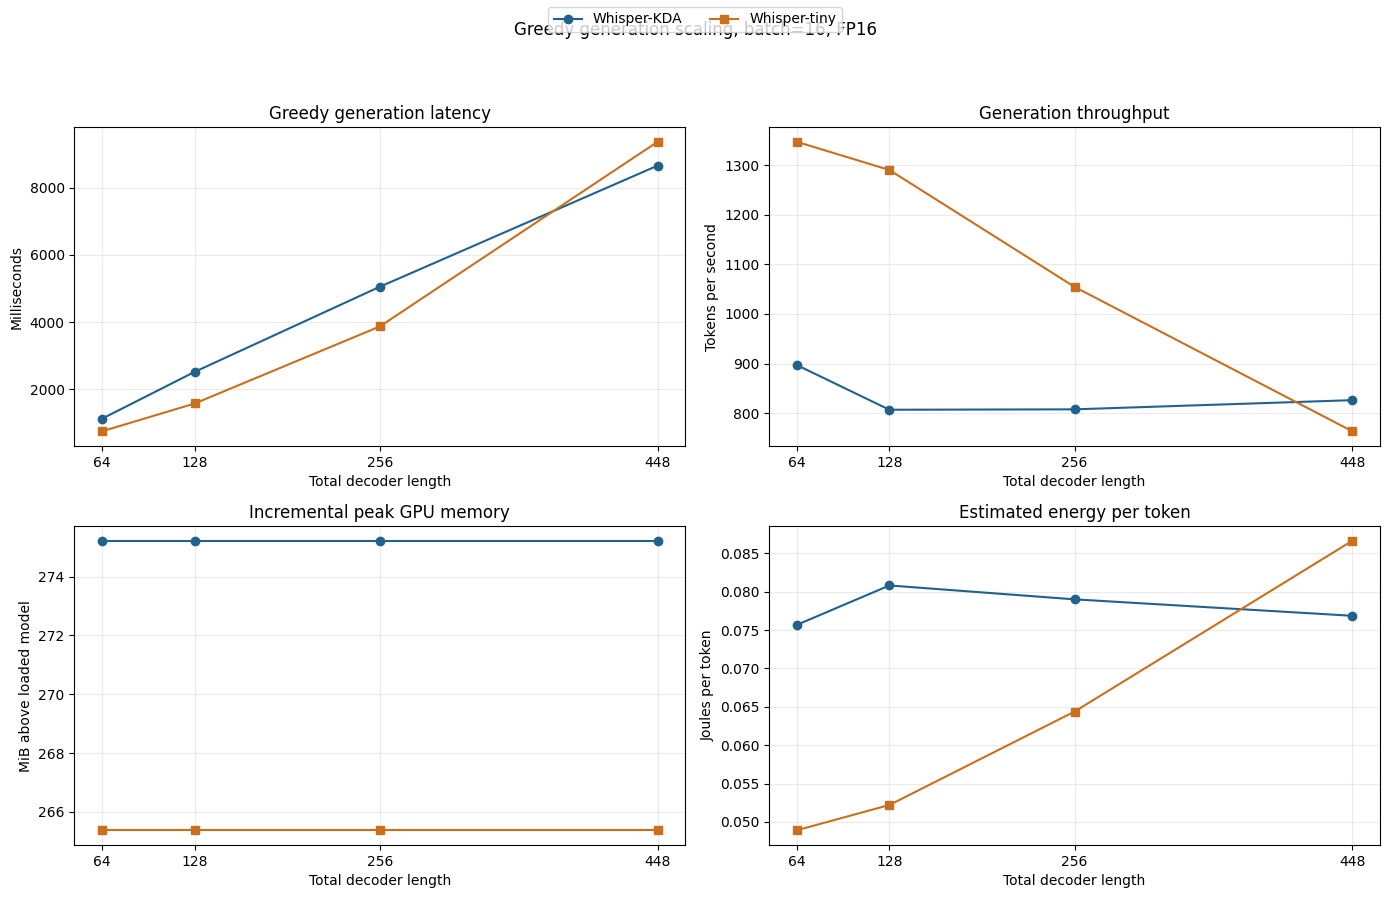

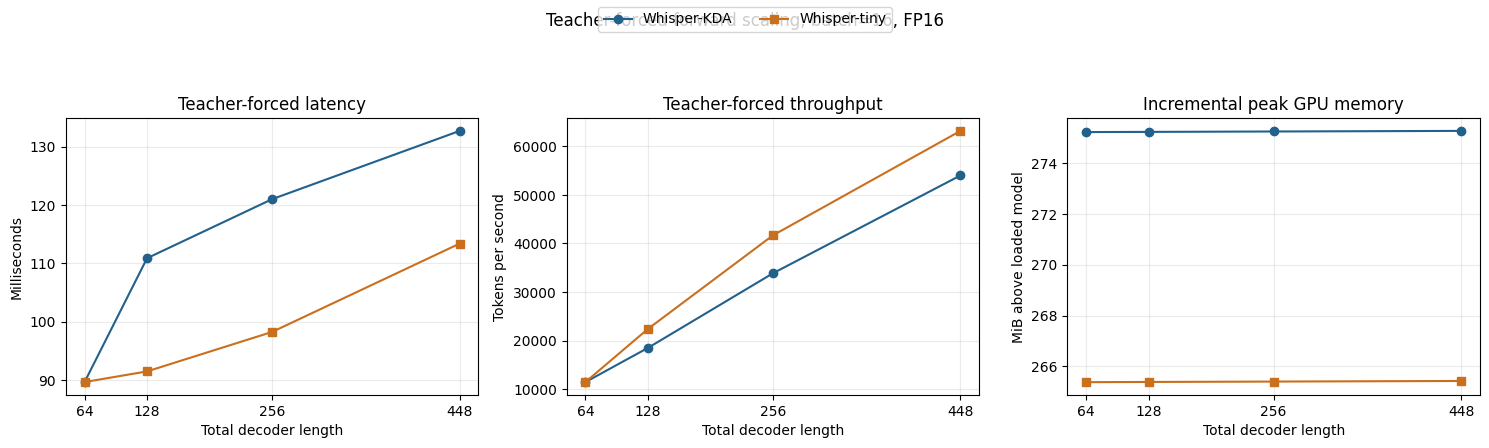

Results: whisper_kda_vs_whisper_tiny_t4_batch16_vocab6390_no_cache.csv


In [10]:
import matplotlib.pyplot as plt
import pandas as pd

RESULTS_PATH = "whisper_kda_vs_whisper_tiny_t4_batch16_vocab6390_no_cache.csv"

if "results" in globals() and results:
    results_df = pd.DataFrame(results)
    results_df["tokens_per_second"] = (
        results_df["processed_tokens"]
        / (results_df["median_ms"] / 1000)
    )
    results_df["estimated_energy_per_token_j"] = (
        results_df["estimated_energy_per_call_j"]
        / results_df["processed_tokens"]
    )
    results_df.insert(0, "measured_runs", MEASURED_RUNS)
    results_df.insert(0, "warmup_runs", WARMUP_RUNS)
    results_df.insert(0, "batch_size", BATCH_SIZE)
    results_df.insert(0, "precision", "FP16")
    results_df.insert(0, "gpu", torch.cuda.get_device_name(device))
    results_df.to_csv(RESULTS_PATH, index=False)
else:
    results_df = pd.read_csv(RESULTS_PATH)
    BATCH_SIZE = int(results_df["batch_size"].iloc[0])
    BENCHMARK_LENGTHS = tuple(
        sorted(results_df["decoder_length"].unique())
    )

columns = [
    "gpu",
    "precision",
    "batch_size",
    "model",
    "benchmark",
    "decoder_length",
    "generation_state",
    "parameters_m",
    "incremental_peak_memory_mb",
    "median_ms",
    "tokens_per_second",
    "avg_gpu_utilization_pct",
    "avg_power_w",
    "estimated_energy_per_token_j",
]

display(results_df[columns].round(3))


def draw_scaling(ax, data, column, title, ylabel):
    styles = {
        "Whisper-KDA": ("#21618c", "o"),
        "Whisper-tiny": ("#ca6f1e", "s"),
    }

    for model_name, group in data.groupby("model", sort=False):
        group = group.sort_values("decoder_length")
        color, marker = styles[model_name]
        ax.plot(
            group["decoder_length"],
            group[column],
            label=model_name,
            color=color,
            marker=marker,
            linestyle="-",
        )

    ax.set_title(title)
    ax.set_xlabel("Total decoder length")
    ax.set_ylabel(ylabel)
    ax.set_xticks(BENCHMARK_LENGTHS)
    ax.grid(alpha=0.25)


generation = results_df[
    results_df["benchmark"] == "greedy_generation"
].copy()

generation_comparison = generation.pivot_table(
    index="decoder_length",
    columns="model",
    values=["median_ms", "incremental_peak_memory_mb"],
    aggfunc="first",
)
kda_advantage = pd.DataFrame({
    "KDA speedup vs Whisper": (
        generation_comparison["median_ms"]["Whisper-tiny"]
        / generation_comparison["median_ms"]["Whisper-KDA"]
    ),
    "KDA memory saving, %": 100 * (
        1
        - generation_comparison["incremental_peak_memory_mb"]["Whisper-KDA"]
        / generation_comparison["incremental_peak_memory_mb"]["Whisper-tiny"]
    ),
})
display(kda_advantage.round(3))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
draw_scaling(
    axes[0, 0],
    generation,
    "median_ms",
    "Greedy generation latency",
    "Milliseconds",
)
draw_scaling(
    axes[0, 1],
    generation,
    "tokens_per_second",
    "Generation throughput",
    "Tokens per second",
)
draw_scaling(
    axes[1, 0],
    generation,
    "incremental_peak_memory_mb",
    "Incremental peak GPU memory",
    "MiB above loaded model",
)
draw_scaling(
    axes[1, 1],
    generation,
    "estimated_energy_per_token_j",
    "Estimated energy per token",
    "Joules per token",
)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
fig.suptitle(
    f"Greedy generation scaling, batch={BATCH_SIZE}, FP16",
    y=0.98,
)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

forward = results_df[
    results_df["benchmark"] == "teacher_forced_forward"
].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
draw_scaling(
    axes[0],
    forward,
    "median_ms",
    "Teacher-forced latency",
    "Milliseconds",
)
draw_scaling(
    axes[1],
    forward,
    "tokens_per_second",
    "Teacher-forced throughput",
    "Tokens per second",
)
draw_scaling(
    axes[2],
    forward,
    "incremental_peak_memory_mb",
    "Incremental peak GPU memory",
    "MiB above loaded model",
)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
fig.suptitle(
    f"Teacher-forced forward scaling, batch={BATCH_SIZE}, FP16",
    y=0.98,
)
plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

print("Results:", RESULTS_PATH)